<a href="https://colab.research.google.com/github/disha-002/DeepLearning/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PART-1**

In [66]:
import numpy as np
np.random.seed(40)

In [67]:
N=3000
x1=np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)
X=np.array([x1, x2]).T
y = (x1**2 + x2**2 > 1.5).astype(int)
y = y.reshape(-1,1)

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [69]:
Model_A = [2, 8, 1]
Model_B = [2, 8, 8, 8, 8, 1]
Model_C = [2,8,8,8,8,8,8,8,8,8,1]

def initialize(layers):
    params = {}
    for l in range(1,len(layers)):
        params["W"+str(l)] = np.random.randn(layers[l], layers[l-1])
        params["b"+str(l)] = np.zeros((layers[l],1))
    return params

Model A

layer 1:(2+1)*8 =24

layer 2:(8+1)*1 = 9

total = 33

Model B


layer 1:(2+1)*8 =24

layer 2:(8+1)*8 = 72

layer 3:(8+1)*8 = 72

layer 4:(8+1)*8 = 72

layer 5:(8+1)*1 = 9

total = 249


Model B


layer 1:(2+1)*8 =24

layer 2:(8+1)*8 = 72

layer 3:(8+1)*8 = 72

layer 4:(8+1)*8 = 72

layer 5:(8+1)*8 = 72

layer 6:(8+1)*8 = 72

layer 7:(8+1)*8 = 72

layer 8:(8+1)*8 = 72

layer 9:(8+1)*8 = 72

layer 10:(8+1)*1 = 9

total = 609

In [70]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

In [71]:
def dsigmoid(z):
    s = sigmoid(z)
    return s*(1-s)

def drelu(z):
    return (z>0).astype(float)

In [72]:
def forward(X, params, activation):

    cache = {}

    A = X.T
    cache["A0"] = A

    L = len(params)//2

    for l in range(1, L):

        Z = params["W"+str(l)] @ A + params["b"+str(l)]
        A = activation(Z)

        cache["Z"+str(l)] = Z
        cache["A"+str(l)] = A

    # output layer
    ZL = params["W"+str(L)] @ A + params["b"+str(L)]
    AL = sigmoid(ZL)

    cache["Z"+str(L)] = ZL
    cache["A"+str(L)] = AL

    return AL.T, cache

In [73]:
def BCE(y, y_hat):

    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1-eps)

    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

In [74]:
def accuracy(y, y_hat):

    y_pred = (y_hat >= 0.5).astype(int)

    return np.mean(y_pred == y)

In [75]:
def backward(X, y, params, cache, activation_deriv):

    grads = {}
    N = X.shape[0]
    L = len(params)//2

    y_hat = cache["A"+str(L)].T

    dA = (y_hat - y)/N
    dA = dA.T

    # output layer
    dZ = dA

    grads["dW"+str(L)] = dZ @ cache["A"+str(L-1)].T
    grads["db"+str(L)] = np.sum(dZ, axis=1, keepdims=True)

    dA_prev = params["W"+str(L)].T @ dZ

    for l in reversed(range(1,L)):

        dZ = dA_prev * activation_deriv(cache["Z"+str(l)])

        grads["dW"+str(l)] = dZ @ cache["A"+str(l-1)].T
        grads["db"+str(l)] = np.sum(dZ, axis=1, keepdims=True)

        dA_prev = params["W"+str(l)].T @ dZ

    return grads

In [76]:
def update_sgd(params, grads, lr):

    L = len(params)//2

    for l in range(1,L+1):

        params["W"+str(l)] -= lr * grads["dW"+str(l)]
        params["b"+str(l)] -= lr * grads["db"+str(l)]

    return params

In [77]:
def init_velocity(params):

    v = {}
    L = len(params)//2

    for l in range(1,L+1):

        v["dW"+str(l)] = np.zeros_like(params["W"+str(l)])
        v["db"+str(l)] = np.zeros_like(params["b"+str(l)])

    return v

In [78]:
def update_momentum(params, grads, v, lr, beta=0.9):

    L = len(params)//2

    for l in range(1,L+1):

        v["dW"+str(l)] = beta*v["dW"+str(l)] + lr*grads["dW"+str(l)]
        v["db"+str(l)] = beta*v["db"+str(l)] + lr*grads["db"+str(l)]

        params["W"+str(l)] -= v["dW"+str(l)]
        params["b"+str(l)] -= v["db"+str(l)]

    return params, v

In [79]:
def grad_norm(grad):

    return np.linalg.norm(grad)

In [80]:
def train(X_train,y_train,X_val,y_val,layers,activation,activation_deriv,
          optimizer="sgd",lr=0.01,epochs=500):

    grad_first_hist = []
    grad_last_hist = []

    params = initialize(layers)

    train_loss_hist = []
    train_acc_hist = []

    val_loss_hist = []
    val_acc_hist = []

    if optimizer == "momentum":
        v = init_velocity(params)

    for epoch in range(epochs):

        # training forward pass
        y_hat,cache = forward(X_train,params,activation)

        loss = BCE(y_train,y_hat)
        acc = accuracy(y_train,y_hat)

        train_loss_hist.append(loss)
        train_acc_hist.append(acc)

        # validation forward pass
        y_val_hat,_ = forward(X_val,params,activation)

        val_loss = BCE(y_val,y_val_hat)
        val_acc = accuracy(y_val,y_val_hat)

        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        grads = backward(X_train,y_train,params,cache,activation_deriv)

        g1 = grad_norm(grads["dW1"])
        g_last = grad_norm(grads["dW"+str(len(layers)-1)])

        grad_first_hist.append(g1)
        grad_last_hist.append(g_last)

        if optimizer == "sgd":
            params = update_sgd(params,grads,lr)

        else:
            params,v = update_momentum(params,grads,v,lr)

    return params, train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, grad_first_hist, grad_last_hist

In [81]:
def evaluate(X, y, params, activation):

    y_hat,_ = forward(X, params, activation)

    loss = BCE(y, y_hat)
    acc = accuracy(y, y_hat)

    return loss, acc

In [82]:
architectures = {
    "Model_A": Model_A,
    "Model_B": Model_B,
    "Model_C": Model_C
}

activations = {
    "relu": (relu, drelu),
    "sigmoid": (sigmoid, dsigmoid)
}

optimizers = ["sgd", "momentum"]

In [83]:
results = []

for arch_name, layers in architectures.items():

    for act_name, (act, dact) in activations.items():

        for opt in optimizers:

            print("\nTraining:", arch_name, act_name, opt)

            params, loss_hist, acc_hist, val_loss_hist, val_acc_hist, grad_first_hist, grad_last_hist = train(
                      X_train,y_train,X_val,y_val,layers,act,dact,optimizer=opt)

            train_loss, train_acc = evaluate(X_train, y_train, params, act)
            val_loss, val_acc = evaluate(X_val, y_val, params, act)
            test_loss, test_acc = evaluate(X_test, y_test, params, act)

            results.append({
                "architecture": arch_name,
                "activation": act_name,
                "optimizer": opt,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "test_acc": test_acc
            })


Training: Model_A relu sgd

Training: Model_A relu momentum

Training: Model_A sigmoid sgd

Training: Model_A sigmoid momentum

Training: Model_B relu sgd

Training: Model_B relu momentum

Training: Model_B sigmoid sgd

Training: Model_B sigmoid momentum

Training: Model_C relu sgd

Training: Model_C relu momentum


/tmp/ipykernel_418/1868565679.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))



Training: Model_C sigmoid sgd

Training: Model_C sigmoid momentum


In [84]:
import pandas as pd

df = pd.DataFrame(results)

df

,architecture,activation,optimizer,train_acc,val_acc,test_acc
0,Model_A,relu,sgd,0.837619,0.820000,0.828889
1,Model_A,relu,momentum,0.965238,0.951111,0.960000
2,Model_A,sigmoid,sgd,0.707619,0.693333,0.700000
3,Model_A,sigmoid,momentum,0.707619,0.693333,0.700000
4,Model_B,relu,sgd,0.966190,0.951111,0.957778
5,Model_B,relu,momentum,0.993333,0.986667,0.984444
6,Model_B,sigmoid,sgd,0.707619,0.693333,0.700000
7,Model_B,sigmoid,momentum,0.707619,0.693333,0.700000
8,Model_C,relu,sgd,0.841429,0.826667,0.826667
9,Model_C,relu,momentum,0.707619,0.693333,0.700000


In [85]:
import matplotlib.pyplot as plt

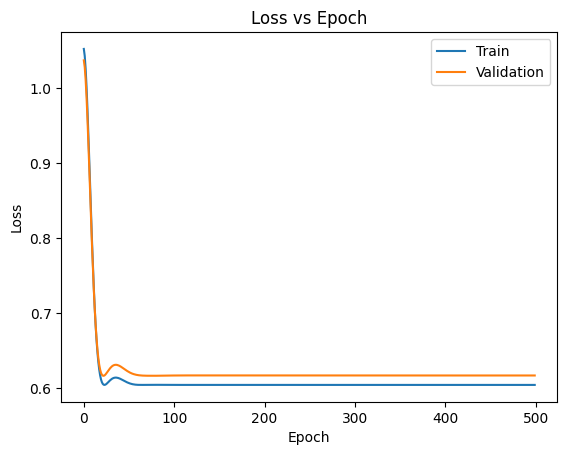

In [86]:
plt.plot(loss_hist,label="Train")
plt.plot(val_loss_hist,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epoch")

plt.show()

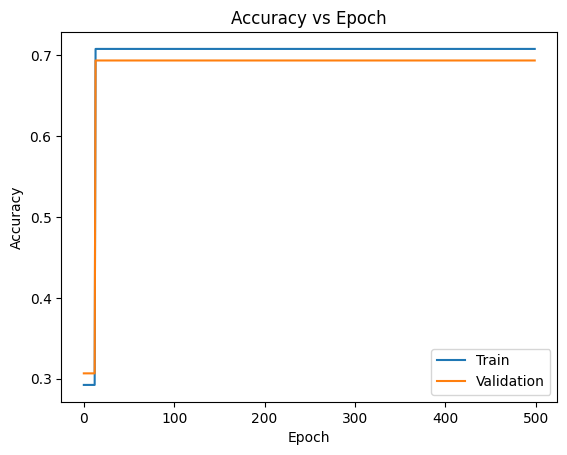

In [87]:
plt.plot(acc_hist,label="Train")
plt.plot(val_acc_hist,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")

plt.show()

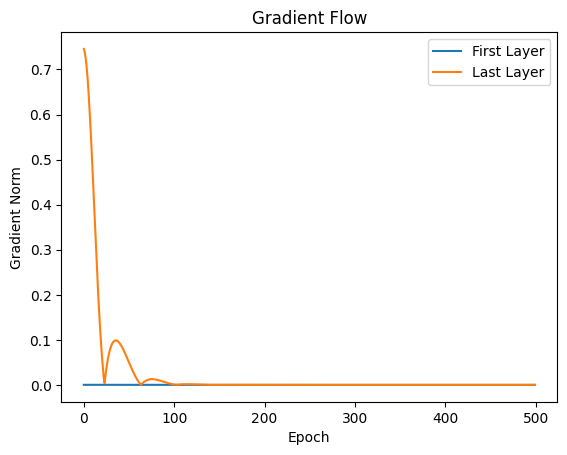

In [88]:
plt.plot(grad_first_hist,label="First Layer")
plt.plot(grad_last_hist,label="Last Layer")

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")

plt.legend()
plt.title("Gradient Flow")

plt.show()

The gradient of the last layer is very high indicating large change in parameters , and when the gradient of the first layer is calculated , it is the same throughout training.

Increasing depth does not always increase model accuracy

as depth increases slightly the test performance increase but on further increase , it decreases

Sigmoid networks remain the same

No , optimizer choice does not affect deep networks more than shallow ones

yes , validation performance predicts test performance reliably.

**PART-2**

In [89]:
import numpy as np

N = 3000
size = 8

X = []
y = []

for i in range(N):

    img = np.zeros((size,size))

    if np.random.rand() < 0.5:
        img[:, size//2] = 1
        label = 0
    else:
        img[size//2, :] = 1
        label = 1

    img += np.random.normal(0,0.1,(size,size))

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y).reshape(-1,1)

In [90]:
from sklearn.model_selection import train_test_split

X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img, y_temp_img, test_size=0.5, random_state=42
)

In [91]:
X_train = X_train_img.reshape(len(X_train_img),64)
X_val = X_val_img.reshape(len(X_val_img),64)
X_test = X_test_img.reshape(len(X_test_img),64)

y_train = y_train_img
y_val = y_val_img
y_test = y_test_img

print("Flattened Train shape:", X_train.shape)

Flattened Train shape: (2100, 64)


In [92]:
dense_arch = [64, 32, 1]

parameters =

(64+1) *32 = 2080

(32+1) *1 = 33

total = 2113



In [93]:
params, train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, grad_first_hist, grad_last_hist = train(
    X_train,
    y_train,
    X_val,
    y_val,
    dense_arch,
    relu,
    drelu,
    optimizer="momentum",
    lr=0.01,
    epochs=500
)

In [94]:
train_loss, train_acc = evaluate(X_train, y_train, params, relu)

val_loss, val_acc = evaluate(X_val, y_val, params, relu)

test_loss, test_acc = evaluate(X_test, y_test, params, relu)

In [95]:
print("===== Dense Baseline Results =====")
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Test Loss:", test_loss)

===== Dense Baseline Results =====
Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 1.0
Train Loss: 0.00013878801515946877
Validation Loss: 0.0001041906058119026
Test Loss: 0.00014907174471183224


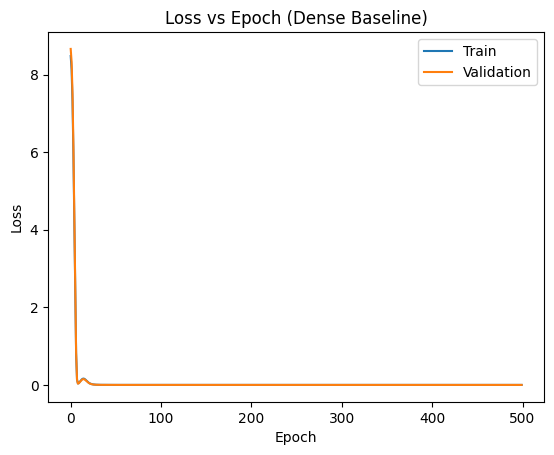

In [96]:
import matplotlib.pyplot as plt

plt.plot(train_loss_hist, label="Train")
plt.plot(val_loss_hist, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epoch (Dense Baseline)")
plt.show()

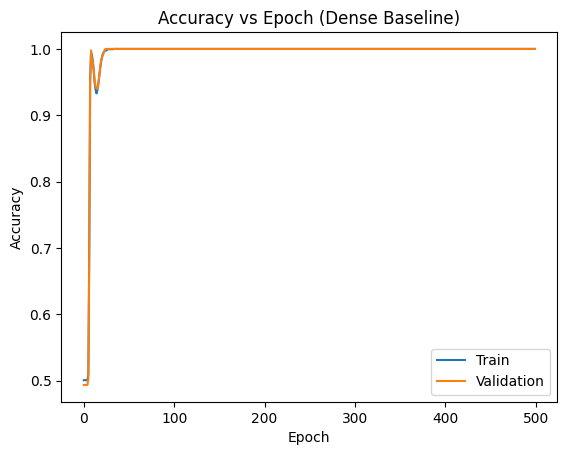

In [97]:
plt.plot(train_acc_hist, label="Train")
plt.plot(val_acc_hist, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch (Dense Baseline)")
plt.show()

In [98]:
def convolution(image, kernel):

    k = kernel.shape[0]
    h, w = image.shape

    out_h = h - k + 1
    out_w = w - k + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            region = image[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output

In [99]:
def flatten(x):
    return x.reshape(-1,1)

In [100]:
def dense_forward(x, W, b):

    z = W @ x + b
    y_hat = sigmoid(z)

    return y_hat

In [101]:
# dense layer parameters
W_dense = np.random.randn(1,9) * 0.01
b_dense = np.zeros((1,1))

In [102]:
def cnn_forward(image, kernel, W, b):

    conv = convolution(image, kernel)

    relu_out = relu(conv)

    pooled = max_pool(relu_out)

    flat = pooled.reshape(-1,1)

    z = W @ flat + b

    y_hat = sigmoid(z)

    return y_hat

In [103]:
kernel = np.random.randn(3,3) * 0.01

In [104]:
def max_pool(feature_map, size=2):

    h, w = feature_map.shape

    out_h = h // size
    out_w = w // size

    pooled = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            region = feature_map[i*size:(i+1)*size,
                                 j*size:(j+1)*size]

            pooled[i,j] = np.max(region)

    return pooled

In [105]:
def cnn_backward(image, label, kernel, W_dense, b_dense, lr):

    # forward
    conv = convolution(image, kernel)
    relu_out = relu(conv)
    pooled = max_pool(relu_out)

    flat = pooled.reshape(-1,1)

    z = W_dense @ flat + b_dense
    y_hat = sigmoid(z)

    # gradient of loss
    dz = y_hat - label

    # dense gradients
    dW_dense = dz @ flat.T
    db_dense = dz

    dflat = W_dense.T @ dz

    dpool = dflat.reshape(pooled.shape)

    # upsample pooling gradient
    drelu = np.repeat(np.repeat(dpool,2,axis=0),2,axis=1)

    # relu gradient
    drelu[conv <= 0] = 0

    # convolution gradient
    k = kernel.shape[0]
    dkernel = np.zeros_like(kernel)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            region = image[i:i+k, j:j+k]
            dkernel += drelu[i,j] * region

    # update parameters
    W_dense -= lr * dW_dense
    b_dense -= lr * db_dense
    kernel -= lr * dkernel

    return kernel, W_dense, b_dense

In [106]:
epochs = 20
lr = 0.01

for epoch in range(epochs):

    total_loss = 0

    for i in range(len(X_train_img)):

        image = X_train_img[i]
        label = y_train_img[i]

        y_hat = cnn_forward(image, kernel, W_dense, b_dense)

        loss = BCE(label, y_hat)

        total_loss += loss

        kernel, W_dense, b_dense = cnn_backward(
            image, label, kernel, W_dense, b_dense, lr
        )

    print("Epoch:", epoch, "Loss:", total_loss/len(X_train_img))

Epoch: 0 Loss: 0.19258936315736347
Epoch: 1 Loss: 0.00217514541897747
Epoch: 2 Loss: 0.0009844788070906797
Epoch: 3 Loss: 0.0006232089980159218
Epoch: 4 Loss: 0.0004506831793435687
Epoch: 5 Loss: 0.00035051433503224876
Epoch: 6 Loss: 0.0002854578699300281
Epoch: 7 Loss: 0.00023998865395466717
Epoch: 8 Loss: 0.00020651559518300168
Epoch: 9 Loss: 0.00018090292780349452
Epoch: 10 Loss: 0.0001607068109583561
Epoch: 11 Loss: 0.000144397719615593
Epoch: 12 Loss: 0.00013096735987940333
Epoch: 13 Loss: 0.00011972597017657735
Epoch: 14 Loss: 0.00011018628655290129
Epoch: 15 Loss: 0.00010199469514907022
Epoch: 16 Loss: 9.488832522621859e-05
Epoch: 17 Loss: 8.866811637682595e-05
Epoch: 18 Loss: 8.318060540917449e-05
Epoch: 19 Loss: 7.830545851518681e-05


In [107]:
correct = 0

for i in range(len(X_test_img)):

    image = X_test_img[i]
    label = y_test_img[i]

    y_hat = cnn_forward(image, kernel, W_dense, b_dense)

    pred = (y_hat >= 0.5).astype(int)

    if pred == label:
        correct += 1

print("Test Accuracy:", correct/len(X_test))
print("Train Accuracy:", correct/len(X_train))
print("Validation Accuracy:", correct/len(X_val))

Test Accuracy: 1.0
Train Accuracy: 0.21428571428571427
Validation Accuracy: 1.0


**Paramter Comparison:**

Dense layer = 2113

CNN = (3 * 3 * 1) * 1 + 1 = 10

for the dense layer , the parameter increases with the increase in the input size whereas in CNN it increases with increase in kernel size.

In [108]:
def cnn_forward_no_pool(image, kernel, W, b):

    conv = convolution(image, kernel)

    relu_out = relu(conv)

    flat = relu_out.reshape(-1,1)

    z = W @ flat + b

    y_hat = sigmoid(z)

    return y_hat

In [109]:
def dropout(x, p=0.5):

    mask = (np.random.rand(*x.shape) < p)

    return x * mask

In [110]:
def cnn_forward_dropout(image, kernel, W, b, p=0.5):

    conv = convolution(image, kernel)

    relu_out = relu(conv)

    pooled = max_pool(relu_out)

    drop = dropout(pooled, p)

    flat = drop.reshape(-1,1)

    z = W @ flat + b

    y_hat = sigmoid(z)

    return y_hat

In [111]:
def train_cnn(X_train, y_train, X_val, y_val, kernel, W, b, forward_fn, epochs=10, lr=0.01):

    train_loss_hist = []
    val_loss_hist = []
    train_acc_hist = []
    val_acc_hist = []

    for epoch in range(epochs):

        total_loss = 0

        for i in range(len(X_train)):

            image = X_train[i]
            label = y_train[i]

            y_hat = forward_fn(image, kernel, W, b)

            loss = BCE(label, y_hat)
            total_loss += loss

            if forward_fn == cnn_forward_no_pool:

                # only update dense layer
                flat = convolution(image, kernel)
                flat = relu(flat).reshape(-1,1)

                z = W @ flat + b
                y_hat = sigmoid(z)

                dz = y_hat - label

                dW = dz @ flat.T
                db = dz

                W -= lr * dW
                b -= lr * db

            else:

                kernel, W, b = cnn_backward(
                    image, label, kernel, W, b, lr
                )

        train_loss = total_loss / len(X_train)

        # evaluate train + validation
        train_loss_eval, train_acc = evaluate_cnn(X_train, y_train, kernel, W, b, forward_fn)
        val_loss, val_acc = evaluate_cnn(X_val, y_val, kernel, W, b, forward_fn)

        train_loss_hist.append(train_loss_eval)
        val_loss_hist.append(val_loss)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print("Epoch:", epoch, "Train Loss:", train_loss_eval, "Val Loss:", val_loss)

    return kernel, W, b, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist

In [112]:
def evaluate_cnn(X, y, kernel, W, b, forward_fn):

    correct = 0
    total_loss = 0

    for i in range(len(X)):

        image = X[i]
        label = y[i]

        y_hat = forward_fn(image, kernel, W, b)

        loss = BCE(label, y_hat)
        total_loss += loss

        pred = (y_hat >= 0.5).astype(int)

        if pred == label:
            correct += 1

    avg_loss = total_loss / len(X)
    accuracy = correct / len(X)

    return avg_loss, accuracy

In [113]:
print("CNN with Pooling")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

kernel, W_dense, b_dense, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    X_train_img,
    y_train_img,
    X_val_img,
    y_val_img,
    kernel,
    W_dense,
    b_dense,
    cnn_forward
)

train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense,b_dense,cnn_forward
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

CNN with Pooling
Epoch: 0 Train Loss: 0.6940552293680476 Val Loss: 0.6934198997935482
Epoch: 1 Train Loss: 0.6930376237043785 Val Loss: 0.6923702052069635
Epoch: 2 Train Loss: 0.6828891038455304 Val Loss: 0.6819524165894084
Epoch: 3 Train Loss: 0.5994933021177411 Val Loss: 0.5966270617764667
Epoch: 4 Train Loss: 0.34456661257288923 Val Loss: 0.3378379603230183
Epoch: 5 Train Loss: 0.12173667556052736 Val Loss: 0.12191880619103634
Epoch: 6 Train Loss: 0.028668015968565528 Val Loss: 0.029113587829212983
Epoch: 7 Train Loss: 0.015301049539483046 Val Loss: 0.015491460508329337
Epoch: 8 Train Loss: 0.01024982225718528 Val Loss: 0.010346412380698123
Epoch: 9 Train Loss: 0.007633990440850971 Val Loss: 0.007695978840717226
Train_accuracy: 1.0 Val_accuracy: 1.0 Test_accuracy: 1.0
Train_loss: 0.007633990440850971 Val_loss: 0.007695978840717226 Test_loss: 0.009020666533061593


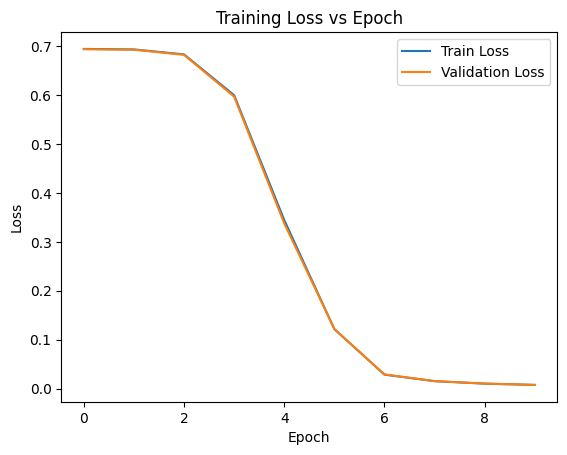

In [114]:
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss vs Epoch")
plt.show()

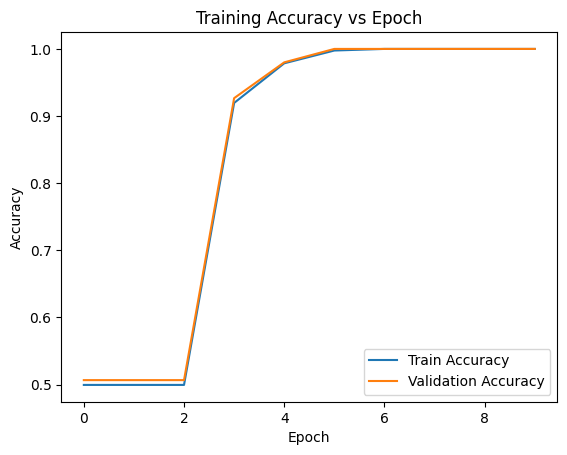

In [115]:
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(val_acc_hist, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training Accuracy vs Epoch")
plt.show()

In [117]:
print("CNN without Pooling")

kernel = np.random.randn(3,3)*0.01
W_dense_no_pool = np.random.randn(1,36)*0.01
b_dense_no_pool = np.zeros((1,1))

kernel, W_dense_no_pool, b_dense_no_pool, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    X_train_img,
    y_train_img,
    X_val_img,
    y_val_img,
    kernel,
    W_dense_no_pool,
    b_dense_no_pool,
    cnn_forward_no_pool
)

train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense_no_pool,b_dense_no_pool,cnn_forward_no_pool
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense_no_pool,b_dense_no_pool,cnn_forward_no_pool
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense_no_pool,b_dense_no_pool,cnn_forward_no_pool
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

CNN without Pooling
Epoch: 0 Train Loss: 0.6902213016920572 Val Loss: 0.6896062895388596
Epoch: 1 Train Loss: 0.6864492034716402 Val Loss: 0.6858519454643865
Epoch: 2 Train Loss: 0.6826955495984066 Val Loss: 0.6821191120016836
Epoch: 3 Train Loss: 0.6789704911769257 Val Loss: 0.6784146755886535
Epoch: 4 Train Loss: 0.6752738616415415 Val Loss: 0.6747384544543324
Epoch: 5 Train Loss: 0.6716054415231935 Val Loss: 0.671090230817939
Epoch: 6 Train Loss: 0.6679650119976206 Val Loss: 0.6674697876287683
Epoch: 7 Train Loss: 0.6643523551840379 Val Loss: 0.6638769087770483
Epoch: 8 Train Loss: 0.6607672541660742 Val Loss: 0.6603113791140269
Epoch: 9 Train Loss: 0.6572094930105541 Val Loss: 0.6567729844703656
Train_accuracy: 0.5009523809523809 Val_accuracy: 0.5088888888888888 Test_accuracy: 0.5533333333333333
Train_loss: 0.6572094930105541 Val_loss: 0.6567729844703656 Test_loss: 0.6529467745566025


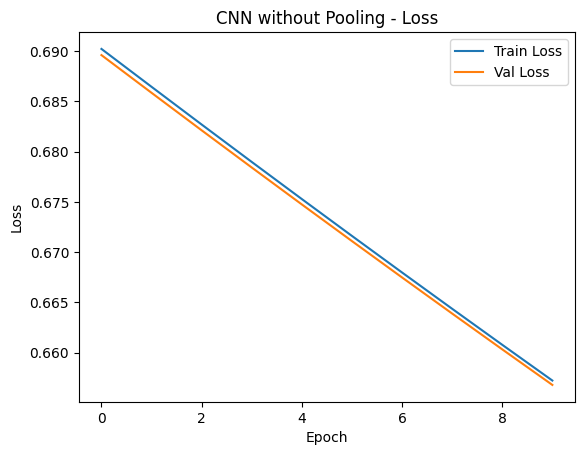

In [118]:
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN without Pooling - Loss")
plt.show()

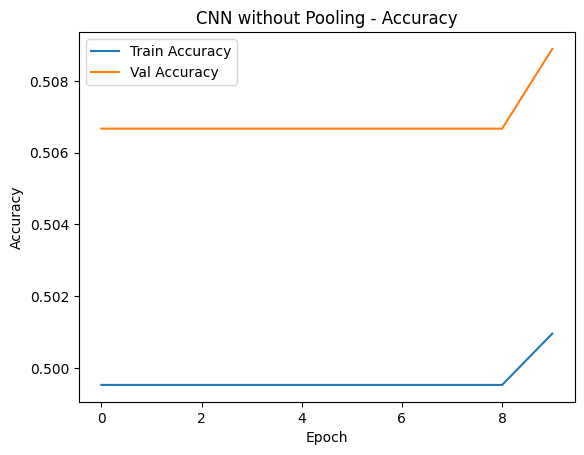

In [119]:
plt.plot(train_acc_hist,label="Train Accuracy")
plt.plot(val_acc_hist,label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN without Pooling - Accuracy")
plt.show()

In [120]:
print("CNN with Dropout")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

kernel, W_dense, b_dense, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    X_train_img,
    y_train_img,
    X_val_img,
    y_val_img,
    kernel,
    W_dense,
    b_dense,
    cnn_forward_dropout
)

train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward_dropout
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward_dropout
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense,b_dense,cnn_forward_dropout
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

CNN with Dropout
Epoch: 0 Train Loss: 0.24244423010386845 Val Loss: 0.22734920444794982
Epoch: 1 Train Loss: 0.24524274025531445 Val Loss: 0.28778694911280567
Epoch: 2 Train Loss: 0.2519285256547851 Val Loss: 0.2287265942880665
Epoch: 3 Train Loss: 0.24626390545715535 Val Loss: 0.2516372126678992
Epoch: 4 Train Loss: 0.24339735730964482 Val Loss: 0.23575360916508423
Epoch: 5 Train Loss: 0.2484440298278191 Val Loss: 0.2459327493165298
Epoch: 6 Train Loss: 0.2572855128754219 Val Loss: 0.24935893145282875
Epoch: 7 Train Loss: 0.25601127744447705 Val Loss: 0.23852786361542355
Epoch: 8 Train Loss: 0.24422895667483036 Val Loss: 0.27221456911165093
Epoch: 9 Train Loss: 0.24973358642331928 Val Loss: 0.19814850471703782
Train_accuracy: 0.7871428571428571 Val_accuracy: 0.7822222222222223 Test_accuracy: 0.7933333333333333
Train_loss: 0.2600316111803369 Val_loss: 0.2695958682416399 Test_loss: 0.2613132842182703


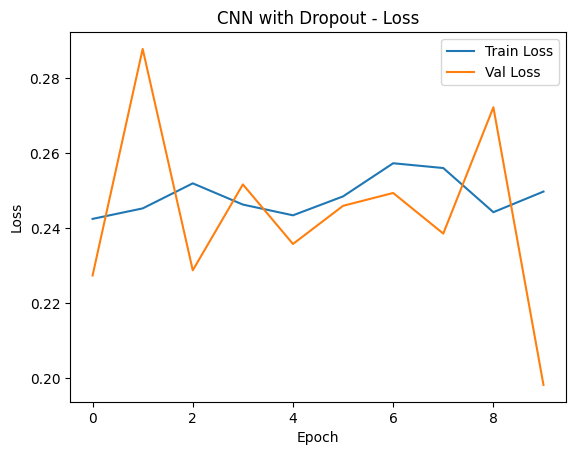

In [121]:
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN with Dropout - Loss")
plt.show()

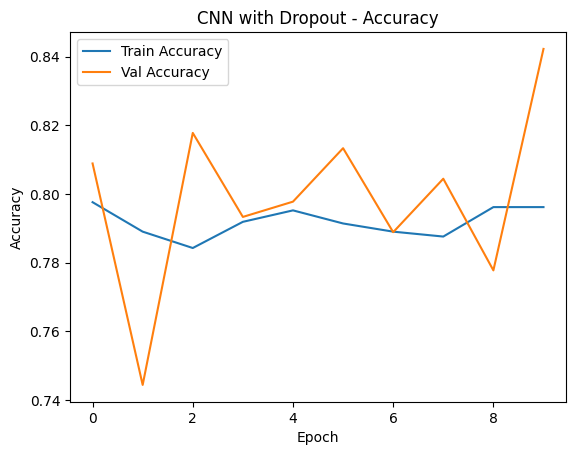

In [122]:
plt.plot(train_acc_hist,label="Train Accuracy")
plt.plot(val_acc_hist,label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN with Dropout - Accuracy")
plt.show()

In [123]:
print("CNN without Dropout")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

kernel, W_dense, b_dense, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    X_train_img,
    y_train_img,
    X_val_img,
    y_val_img,
    kernel,
    W_dense,
    b_dense,
    cnn_forward
)

train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense,b_dense,cnn_forward
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

CNN without Dropout
Epoch: 0 Train Loss: 0.005763716706162782 Val Loss: 0.005763233455295155
Epoch: 1 Train Loss: 0.001594100180317187 Val Loss: 0.0015959828670114589
Epoch: 2 Train Loss: 0.0008753548759686663 Val Loss: 0.0008762754551900525
Epoch: 3 Train Loss: 0.000591243046863998 Val Loss: 0.000591699849086821
Epoch: 4 Train Loss: 0.00044175020253219764 Val Loss: 0.00044195705373971644
Epoch: 5 Train Loss: 0.0003503916448326074 Val Loss: 0.0003504493790541434
Epoch: 6 Train Loss: 0.0002891367321387917 Val Loss: 0.00028909989865810287
Epoch: 7 Train Loss: 0.00024538434225788335 Val Loss: 0.0002452841556991037
Epoch: 8 Train Loss: 0.00021266419628962707 Val Loss: 0.00021252007875818574
Epoch: 9 Train Loss: 0.00018732514626460358 Val Loss: 0.0001871498532494805
Train_accuracy: 1.0 Val_accuracy: 1.0 Test_accuracy: 1.0
Train_loss: 0.00018732514626460358 Val_loss: 0.0001871498532494805 Test_loss: 0.0001888034175680843


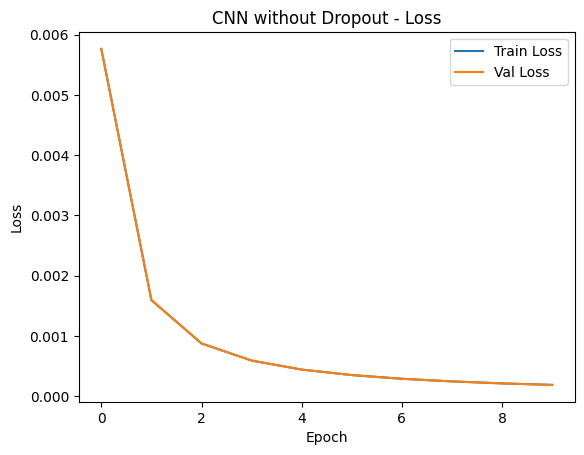

In [124]:
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN without Dropout - Loss")
plt.show()

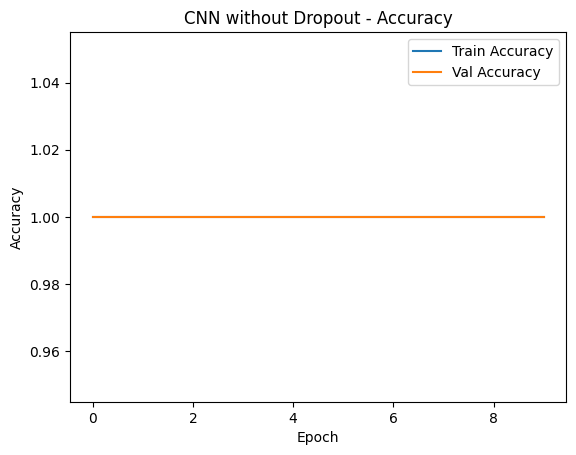

In [125]:
plt.plot(train_acc_hist,label="Train Accuracy")
plt.plot(val_acc_hist,label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN without Dropout - Accuracy")
plt.show()

Both the models(CNN and dense) achieved the same test accuracy.

Yes, pooling improves the test performance.

no , dropout did not reduce the validation - test gap.

CNN has the same test accuracy as the dense but with much fewer parameters.

CNN scales better with larger image size becase the no of parameters does not depend on the image size but on the kernel size.


**PART-3**

In [135]:
print("Training with SGD")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

kernel, W_dense, b_dense, train_loss_sgd, val_loss_sgd, train_acc_sgd, val_acc_sgd = train_cnn(
    X_train_img,
    y_train_img,
    X_val_img,
    y_val_img,
    kernel,
    W_dense,
    b_dense,
    cnn_forward
)

train_loss_sgd,train_acc_sgd = evaluate_cnn(X_train_img,y_train_img,
                                            kernel,W_dense,b_dense,cnn_forward)

val_loss_sgd,val_acc_sgd = evaluate_cnn(X_val_img,y_val_img,
                                        kernel,W_dense,b_dense,cnn_forward)

test_loss_sgd,test_acc_sgd = evaluate_cnn(X_test_img,y_test_img,
                                          kernel,W_dense,b_dense,cnn_forward)

print("===== SGD Results =====")
print("Train_accuracy:",train_acc_sgd,"Val_accuracy:",val_acc_sgd,"Test_accuracy:",test_acc_sgd)
print("Train_loss:",train_loss_sgd,"Val_loss:",val_loss_sgd,"Test_loss:",test_loss_sgd)

Training with SGD
Epoch: 0 Train Loss: 0.00393660997080244 Val Loss: 0.0039028460626038737
Epoch: 1 Train Loss: 0.0013797008606864177 Val Loss: 0.0013671079632656292
Epoch: 2 Train Loss: 0.0008002244354261393 Val Loss: 0.0007923438063728644
Epoch: 3 Train Loss: 0.0005535593698978632 Val Loss: 0.0005477633216767418
Epoch: 4 Train Loss: 0.00041910958676729987 Val Loss: 0.0004144968866774146
Epoch: 5 Train Loss: 0.00033522470343553656 Val Loss: 0.00033137604595435624
Epoch: 6 Train Loss: 0.00027820863506252595 Val Loss: 0.00027489574288257283
Epoch: 7 Train Loss: 0.0002370900597369435 Val Loss: 0.00023417506155164837
Epoch: 8 Train Loss: 0.00020611875343850704 Val Loss: 0.00020351159744857482
Epoch: 9 Train Loss: 0.0001820015321724359 Val Loss: 0.00017963974006460063
===== SGD Results =====
Train_accuracy: 1.0 Val_accuracy: 1.0 Test_accuracy: 1.0
Train_loss: 0.0001820015321724359 Val_loss: 0.00017963974006460063 Test_loss: 0.00017514762894064754


In [127]:
def update_momentum(W, dW, v, lr, beta=0.9):

    v = beta*v + (1-beta)*dW
    W = W - lr*v

    return W, v

In [136]:
print("Training with Momentum")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

vW = np.zeros_like(W_dense)
vb = np.zeros_like(b_dense)

train_loss_mom = []
val_loss_mom = []

train_acc_mom = []
val_acc_mom = []

for epoch in range(10):

    for i in range(len(X_train_img)):

        image = X_train_img[i]
        label = y_train_img[i]

        y_hat = cnn_forward(image, kernel, W_dense, b_dense)

        flat = max_pool(relu(convolution(image,kernel))).reshape(-1,1)

        dz = y_hat - label

        dW = dz @ flat.T
        db = dz

        W_dense, vW = update_momentum(W_dense, dW, vW, 0.01)
        b_dense, vb = update_momentum(b_dense, db, vb, 0.01)

    train_loss, train_acc = evaluate_cnn(
        X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
    )

    val_loss, val_acc = evaluate_cnn(
        X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
    )

    train_loss_mom.append(train_loss)
    val_loss_mom.append(val_loss)

    train_acc_mom.append(train_acc)
    val_acc_mom.append(val_acc)

    print("Epoch:",epoch,"Val loss:",val_loss)

Training with Momentum
Epoch: 0 Val loss: 0.6928364466379849
Epoch: 1 Val loss: 0.6918921512711848
Epoch: 2 Val loss: 0.6909419589976507
Epoch: 3 Val loss: 0.6899935973018986
Epoch: 4 Val loss: 0.6890470984352428
Epoch: 5 Val loss: 0.6881024588971348
Epoch: 6 Val loss: 0.6871596750247666
Epoch: 7 Val loss: 0.686218743157959
Epoch: 8 Val loss: 0.6852796596399585
Epoch: 9 Val loss: 0.6843424208174604


In [137]:
train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense,b_dense,cnn_forward
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

Train_accuracy: 0.49952380952380954 Val_accuracy: 0.5066666666666667 Test_accuracy: 0.5511111111111111
Train_loss: 0.6849572709818001 Val_loss: 0.6843424208174604 Test_loss: 0.6797775794069051


In [129]:
def adam_update(W, dW, m, v, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):

    m = beta1*m + (1-beta1)*dW
    v = beta2*v + (1-beta2)*(dW**2)

    m_hat = m/(1-beta1**t)
    v_hat = v/(1-beta2**t)

    W = W - lr * m_hat/(np.sqrt(v_hat)+eps)

    return W, m, v

In [138]:
print("Training with Adam")

kernel = np.random.randn(3,3)*0.01
W_dense = np.random.randn(1,9)*0.01
b_dense = np.zeros((1,1))

mW = np.zeros_like(W_dense)
vW = np.zeros_like(W_dense)

mb = np.zeros_like(b_dense)
vb = np.zeros_like(b_dense)

train_loss_adam = []
val_loss_adam = []

train_acc_adam = []
val_acc_adam = []

t = 1

for epoch in range(10):

    for i in range(len(X_train_img)):

        image = X_train_img[i]
        label = y_train_img[i]

        y_hat = cnn_forward(image, kernel, W_dense, b_dense)

        flat = max_pool(relu(convolution(image,kernel))).reshape(-1,1)

        dz = y_hat - label

        dW = dz @ flat.T
        db = dz

        W_dense, mW, vW = adam_update(W_dense, dW, mW, vW, 0.01, t)
        b_dense, mb, vb = adam_update(b_dense, db, mb, vb, 0.01, t)

        t += 1

    train_loss, train_acc = evaluate_cnn(
        X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
    )

    val_loss, val_acc = evaluate_cnn(
        X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
    )

    train_loss_adam.append(train_loss)
    val_loss_adam.append(val_loss)

    train_acc_adam.append(train_acc)
    val_acc_adam.append(val_acc)

    print("Epoch:",epoch,"Val loss:",val_loss)

Training with Adam
Epoch: 0 Val loss: 0.6002369305787738
Epoch: 1 Val loss: 0.5172665673536309
Epoch: 2 Val loss: 0.4443304040413542
Epoch: 3 Val loss: 0.3804024859730641
Epoch: 4 Val loss: 0.32471447617680077
Epoch: 5 Val loss: 0.27650993835647003
Epoch: 6 Val loss: 0.23501845199220128
Epoch: 7 Val loss: 0.1994773935441278
Epoch: 8 Val loss: 0.16915575253784962
Epoch: 9 Val loss: 0.14337154314995354


In [139]:
train_loss,train_acc = evaluate_cnn(
    X_train_img,y_train_img,kernel,W_dense,b_dense,cnn_forward
)

val_loss,val_acc = evaluate_cnn(
    X_val_img,y_val_img,kernel,W_dense,b_dense,cnn_forward
)

test_loss,test_acc = evaluate_cnn(
    X_test_img,y_test_img,kernel,W_dense,b_dense,cnn_forward
)

print("Train_accuracy:",train_acc,"Val_accuracy:",val_acc,"Test_accuracy:",test_acc)
print("Train_loss:",train_loss,"Val_loss:",val_loss,"Test_loss:",test_loss)

Train_accuracy: 1.0 Val_accuracy: 1.0 Test_accuracy: 1.0
Train_loss: 0.14254851188054016 Val_loss: 0.14337154314995354 Test_loss: 0.1443897688449133


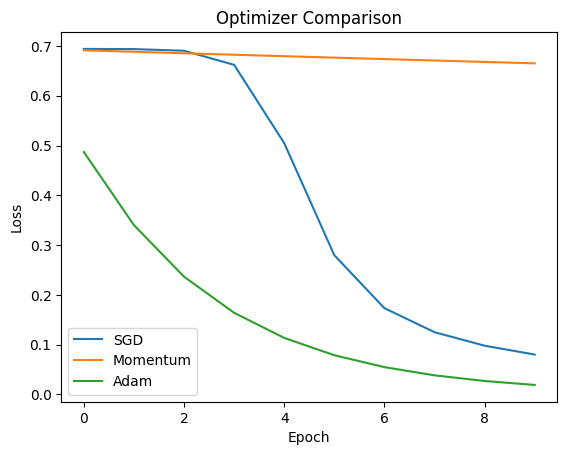

In [131]:
plt.plot(train_loss_sgd,label="SGD")
plt.plot(train_loss_mom,label="Momentum")
plt.plot(train_loss_adam,label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

In [141]:
import pandas as pd

master_data = [

# ---------------- PART 1 : Dense Models ----------------

{"Model":"Model_A","Depth":2,"Activation":"relu","Optimizer":"sgd","Parameters":33,"Train Acc":0.837619,"Val Acc":0.82,"Test Acc":0.828889},
{"Model":"Model_A","Depth":2,"Activation":"relu","Optimizer":"momentum","Parameters":33,"Train Acc":0.965238,"Val Acc":0.951111,"Test Acc":0.96},
{"Model":"Model_A","Depth":2,"Activation":"sigmoid","Optimizer":"sgd","Parameters":33,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},
{"Model":"Model_A","Depth":2,"Activation":"sigmoid","Optimizer":"momentum","Parameters":33,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},

{"Model":"Model_B","Depth":5,"Activation":"relu","Optimizer":"sgd","Parameters":249,"Train Acc":0.96619,"Val Acc":0.951111,"Test Acc":0.957778},
{"Model":"Model_B","Depth":5,"Activation":"relu","Optimizer":"momentum","Parameters":249,"Train Acc":0.993333,"Val Acc":0.986667,"Test Acc":0.984444},
{"Model":"Model_B","Depth":5,"Activation":"sigmoid","Optimizer":"sgd","Parameters":249,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},
{"Model":"Model_B","Depth":5,"Activation":"sigmoid","Optimizer":"momentum","Parameters":249,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},

{"Model":"Model_C","Depth":10,"Activation":"relu","Optimizer":"sgd","Parameters":609,"Train Acc":0.841429,"Val Acc":0.826667,"Test Acc":0.826667},
{"Model":"Model_C","Depth":10,"Activation":"relu","Optimizer":"momentum","Parameters":609,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},
{"Model":"Model_C","Depth":10,"Activation":"sigmoid","Optimizer":"sgd","Parameters":609,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},
{"Model":"Model_C","Depth":10,"Activation":"sigmoid","Optimizer":"momentum","Parameters":609,"Train Acc":0.707619,"Val Acc":0.693333,"Test Acc":0.7},

# ---------------- PART 2 : Dense Baseline ----------------

{"Model":"Dense_Baseline","Depth":2,"Activation":"relu","Optimizer":"-","Parameters":2113,"Train Acc":1.0,"Val Acc":1.0,"Test Acc":1.0},

# ---------------- CNN Architecture Experiments ----------------

{"Model":"CNN","Depth":"-","Activation":"relu","Optimizer":"-","Parameters":10,"Train Acc":0.21428571428571427,"Val Acc":1.0,"Test Acc":1.0},

{"Model":"CNN_pool","Depth":"-","Activation":"relu","Optimizer":"-","Parameters":10,"Train Acc":1.0,"Val Acc":1.0,"Test Acc":1.0},

{"Model":"CNN_no_pool","Depth":"-","Activation":"relu","Optimizer":"-","Parameters":37,"Train Acc":0.5009523809523809,"Val Acc":0.5088888888888888,"Test Acc":0.5533333333333333},

{"Model":"CNN_dropout","Depth":"-","Activation":"relu","Optimizer":"-","Parameters":10,"Train Acc":0.7871428571428571,"Val Acc":0.7822222222222223,"Test Acc":0.7933333333333333},

{"Model":"CNN_no_dropout","Depth":"-","Activation":"relu","Optimizer":"-","Parameters":10,"Train Acc":1.0,"Val Acc":1.0,"Test Acc":1.0},

# ---------------- PART 3 : Optimizer Comparison ----------------

{"Model":"CNN_SGD","Depth":"-","Activation":"relu","Optimizer":"sgd","Parameters":10,"Train Acc":1.0,"Val Acc":1.0,"Test Acc":1.0},

{"Model":"CNN_Momentum","Depth":"-","Activation":"relu","Optimizer":"momentum","Parameters":10,"Train Acc":0.49952380952380954,"Val Acc":0.5066666666666667,"Test Acc":0.5511111111111111},

{"Model":"CNN_Adam","Depth":"-","Activation":"relu","Optimizer":"adam","Parameters":10,"Train Acc":1.0,"Val Acc":1.0,"Test Acc":1.0}

]

master_table = pd.DataFrame(master_data)

master_table

,Model,Depth,Activation,Optimizer,Parameters,Train Acc,Val Acc,Test Acc
0,Model_A,2,relu,sgd,33,0.837619,0.820000,0.828889
1,Model_A,2,relu,momentum,33,0.965238,0.951111,0.960000
2,Model_A,2,sigmoid,sgd,33,0.707619,0.693333,0.700000
3,Model_A,2,sigmoid,momentum,33,0.707619,0.693333,0.700000
4,Model_B,5,relu,sgd,249,0.966190,0.951111,0.957778
5,Model_B,5,relu,momentum,249,0.993333,0.986667,0.984444
6,Model_B,5,sigmoid,sgd,249,0.707619,0.693333,0.700000
7,Model_B,5,sigmoid,momentum,249,0.707619,0.693333,0.700000
8,Model_C,10,relu,sgd,609,0.841429,0.826667,0.826667
9,Model_C,10,relu,momentum,609,0.707619,0.693333,0.700000


Training failed maily when we used sigmoid activation function.

optimizers matter more in the deeper networks.

activation function mattered more when we compared relu with activation for different layers.

sigmoid activation function caused gradient shrinkage

cnn genralize better because of parameter sharing.

dropout reduces overfitting because it diables certain neurons during training.

depth hurts test performance when the model becomes too complex for data and the model begins overfitting

yes , validation predicted test performance mostly correctly.